# Balanceo Dataset

In [1]:
# SOLO PARA COLAB
!pip install imbalanced-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

## Carga del dataset escalado

In [3]:
# SOLO PARA COLAB
!unzip "/content/chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized.csv.zip"

Archive:  /content/chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized.csv.zip
  inflating: chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized.csv  
  inflating: __MACOSX/._chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized.csv  


In [4]:
path_colab = "/content/chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized.csv"
path_local = "../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized.csv"

df = pd.read_csv(path_local)

In [5]:
df.head()


,Beat,Ward,Community Area,Day_sin,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Day Time_Afternoon,Day Time_Early Morning,...,Location_Description_freq,FBI_Code_freq,Crime_District_freq,Nearest_Police_Station_District_freq,Nearest_Police_Station_District_Name_freq,X Coordinate_standardized,Y Coordinate_standardized,Latitude_standardized,Longitude_standardized,Distance Crime To Police Station_standardized
0,332,5,43,0.433884,0.0,0.0,0.0,1.0,0.0,0.0,...,0.192536,0.111732,0.051572,0.094475,0.094475,1.330383,-0.864675,-0.868260,1.228326,-0.382365
1,223,3,38,0.433884,0.0,0.0,0.0,1.0,0.0,0.0,...,0.192536,0.073023,0.050624,0.043242,0.043242,0.888992,-0.439643,-0.442201,0.746381,-0.366757
2,834,18,70,0.433884,0.0,0.0,0.0,1.0,0.0,0.0,...,0.004823,0.032045,0.067287,0.066335,0.066335,-1.203298,-1.090606,-1.083662,-0.774558,1.412487
3,321,20,42,0.433884,0.0,0.0,0.0,1.0,0.0,0.0,...,0.273399,0.111732,0.051572,0.094475,0.094475,1.178956,-0.833068,-0.836054,1.228326,-0.899415
4,2531,29,25,0.433884,0.0,0.0,0.0,1.0,0.0,0.0,...,0.053826,0.149203,0.051706,0.050395,0.050395,-1.714142,0.638315,0.643433,-1.876083,0.076405


## Funciones auxiliares

In [5]:
# Función para calcular la entropía de Shannon
def shannon_entropy(y):
    probs = y.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))

In [6]:
# Función para graficar la distribución de la variable target
def plot(y):
    fig, axes = plt.subplots(figsize=(4, 4))
    sns.countplot(x=y, hue=y, palette="Set2", ax=axes)

    axes.set_xlabel("Arrested")
    axes.set_ylabel("Cantidad")
    axes.set_title(f"Distribución de la variable {target}")

    plt.tight_layout()
    plt.show()

In [7]:
# Evaluación del desbalance
def info(y):
    print("Proporción de clases:")
    print(y.value_counts(normalize=True))
    entropy = shannon_entropy(y)
    print("\nEntropía de Shannon:", entropy)
    plot(y)

## Preparación del dataset

Proporción de clases:
Arrest_tag
0    0.86324
1    0.13676
Name: proportion, dtype: float64

Entropía de Shannon: 0.5756904357932902


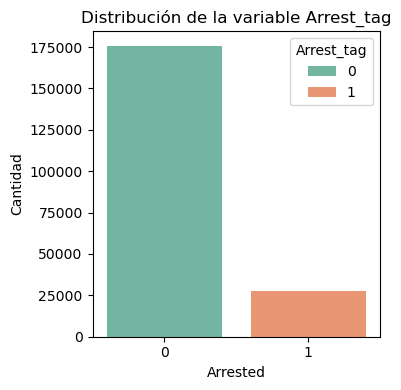

In [8]:
# Separo el dataset en X (variables) y (target)
target = 'Arrest_tag'
X = df.drop(columns=[target])
y = df[target]

# Separa en entrenamiento y test
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17, stratify=y)

info(y) # datos originales

In [ ]:
# Guardo el set de test
#df_test = pd.concat([X_test, y_test], axis=1)
#df_test.to_csv("datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_test.csv", index=False)

## Oversampling con SMOTE

Proporción de clases:
Arrest_tag
0    0.5
1    0.5
Name: proportion, dtype: float64

Entropía de Shannon: 1.0


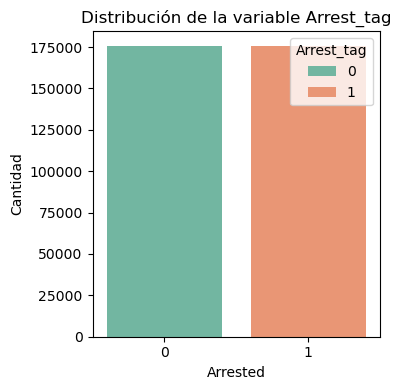

In [9]:
smote = SMOTE(random_state=17)
X_train_sm, y_train_sm = smote.fit_resample(X, y)
info(y_train_sm)

In [ ]:
# Guardo el dataset de entrenamiento con oversampling (SMOTE)
df_smote = pd.concat([X_train_sm, y_train_sm], axis=1)
df_smote.to_csv("datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized_smote.csv", index=False)

## Undersampling

Proporción de clases:
Arrest_tag
0    0.5
1    0.5
Name: proportion, dtype: float64

Entropía de Shannon: 1.0


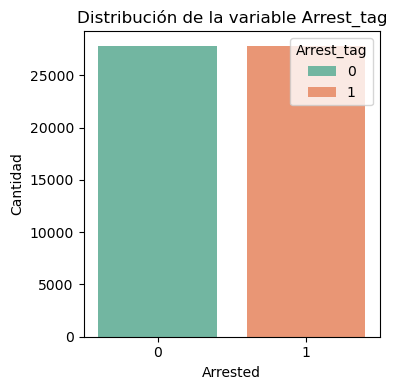

In [10]:
undersample = RandomUnderSampler(random_state=17)
X_train_us, y_train_us = undersample.fit_resample(X, y)
info(y_train_us)

In [ ]:
# Guardo el dataset de entrenamiento con undersampling
df_undersample = pd.concat([X_train_us, y_train_us], axis=1)
df_undersample.to_csv("datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized_undersample.csv", index=False)

## Estrategia Combinada

In [11]:
# Oversampling (SMOTE)
# sampling_strategy=0.5 significa que la clase minoritaria llegará a ser el 50%
# del tamaño de la clase mayoritaria original.
over = SMOTE(sampling_strategy=0.5, random_state=17)

In [12]:
# Undersampling
# sampling_strategy=0.8 significa que, después del undersampling, la clase minoritaria
# tendrá un tamaño equivalente al 80% de la clase mayoritaria.
under = RandomUnderSampler(sampling_strategy=0.8, random_state=17)

In [13]:
# Crear el Pipeline que combina ambos pasos
# El pipeline aplicará los pasos en el orden en que se definen.
steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps=steps)

Proporción de clases:
Arrest_tag
0    0.555554
1    0.444446
Name: proportion, dtype: float64

Entropía de Shannon: 0.9910764217963219


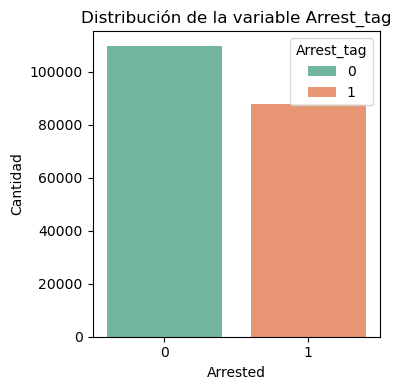

In [14]:
# Aplicar el pipeline a los datos de entrenamiento
X_resampled, y_resampled = pipeline.fit_resample(X, y)
info(y_resampled)

In [16]:
# Guardo el dataset resultante
df_combined = pd.concat([X_resampled, y_resampled], axis=1)
df_combined.to_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized_combined.csv", index=False)